##***Training Models***

###***ML Model Implementation***

### ML Model - 1

In [ ]:
#Apply feature scaling on the dataset for building the logistic regression model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resm)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter = 1000)

# Fit the Algorithm
model_lr.fit(X_train_scaled, y_train_resm)

# Predict on the model
y_pred_lr = model_lr.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8511324488748809
Precision: 0.07450796626054358
Recall: 0.7395348837209302
F1 Score: 0.13537675606641125

Confusion Matrix:
[[22906  3950]
 [  112   318]]


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model_lr.predict_proba(X_test_scaled)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.8503288858407632)

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

[[22906  3950]
 [  112   318]]
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     26856
           1       0.07      0.74      0.14       430

    accuracy                           0.85     27286
   macro avg       0.53      0.80      0.53     27286
weighted avg       0.98      0.85      0.91     27286



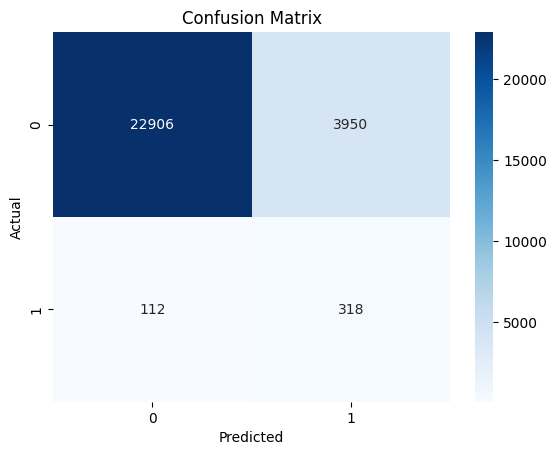

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid_lr = { "C": [0.001, 0.01, 0.1, 1, 10],
              "solver": ["lbfgs", "liblinear"],
               "class_weight": [None, "balanced"] }
# Fit the Algorithm
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    estimator=log_reg,
    param_grid = param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train_resm)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
# Predict on the model

Best Parameters: {'C': 10, 'class_weight': None, 'solver': 'lbfgs'}
Best CV Score: 0.9096638936441848


In [ ]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

In [ ]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92     26856
           1       0.07      0.74      0.14       430

    accuracy                           0.85     27286
   macro avg       0.54      0.80      0.53     27286
weighted avg       0.98      0.85      0.91     27286



In [ ]:
print(confusion_matrix(y_test, y_pred_tuned))

[[22934  3922]
 [  112   318]]


In [ ]:
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.8503288858407632)

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()

#Train the model
model_dt.fit(X_train_resm, y_train_resm)
#make predictions
y_pred_dt = model_dt.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     26856
           1       0.15      0.42      0.22       430

    accuracy                           0.95     27286
   macro avg       0.57      0.69      0.60     27286
weighted avg       0.98      0.95      0.96     27286



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Confusion Matrix:
[[25811  1045]
 [  249   181]]


In [ ]:
y_prob_dt = model_dt.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_dt))

ROC AUC: 0.7021113899453416


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dist_dt = {
    "max_depth": [3,5,7,10,15,None],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,2,4,8],
    "criterion": ["gini","entropy"]
}

random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt,
    n_iter=40,   # sweet spot for your size
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

random_dt.fit(X_train_resm, y_train_resm)

KeyboardInterrupt: 

In [ ]:
print("Best Parameters:", random_dt.best_params_)
print("Best CV Score:", random_dt.best_score_)

In [ ]:
best_dt = random_dt.best_estimator_

y_pred_dt_grid = best_dt.predict(X_test)
y_prob_dt_grid = best_dt.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_dt_grid))

In [ ]:
print(confusion_matrix(y_test, y_pred_dt_grid))

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_dt_grid))

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state = 42)

# Fit the Algorithm
model_rf.fit(X_train_resm, y_train_resm)

# Predict on the model
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:,1]

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     26856
           1       0.29      0.53      0.37       430

    accuracy                           0.97     27286
   macro avg       0.64      0.76      0.68     27286
weighted avg       0.98      0.97      0.98     27286



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix:
[[26284   572]
 [  200   230]]


In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

ROC AUC: 0.8853826783326753


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_dist_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}


from sklearn.model_selection import RandomizedSearchCV
random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=8,               # number of combinations to try
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=2
)


# Fit the Algorithm
random_rf.fit(X_train_resm, y_train_resm)
# Predict on the model

In [ ]:
print('Best_param :', random_rf.best_params_)
print('Best_score :', random_rf.best_score_)

In [ ]:
best_rf = random_rf.best_estimator_

y_pred_rf_grid = best_rf.predict(X_test)
y_prob_rf_grid = best_rf.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test, y_pred_rf_grid))

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_grid))

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf_grid))

In [ ]:
threshold = 0.30
y_pred_rf_grid_new = (y_prob_rf_grid >= threshold).astype(int)

In [ ]:
print(classification_report(y_test, y_pred_rf_grid_new))

In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_grid_new))

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf_grid)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

In [ ]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1:", f1_scores[best_index])

In [ ]:
print(y_prob_rf_grid.min())
print(y_prob_rf_grid.max())

In [ ]:
y_pred_optimal = (y_prob >= best_threshold).astype(int)

In [ ]:
print(classification_report(y_test, y_pred_optimal))

In [ ]:
print(confusion_matrix(y_test, y_pred_optimal))

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

### 3. ML Model - 4

In [ ]:
# Convert to string
X_train_resm.columns = X_train_resm.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Remove illegal characters
X_train_resm.columns = X_train_resm.columns.str.replace(r"[<>\[\]]", "", regex=True)
X_test.columns = X_test.columns.str.replace(r"[<>\[\]]", "", regex=True)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
    )

#Fit the model
xgb_model.fit(X_train_resm, y_train_resm)

#Predict on the model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97     26856
           1       0.19      0.66      0.29       430

    accuracy                           0.95     27286
   macro avg       0.59      0.81      0.63     27286
weighted avg       0.98      0.95      0.96     27286



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Confusion Matrix:
[[25656  1200]
 [  148   282]]


In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC AUC: 0.895305713157512


In [ ]:
param_dist_xgb = {
  "n_estimators": [200, 300, 400],
  "max_depth": [4, 5, 6],
  "learning_rate": [0.03, 0.05, 0.07],
  "subsample": [0.7, 0.8, 0.9],
  "colsample_bytree": [0.7, 0.8, 0.9],
  "gamma": [0, 0.1, 0.3]
}

random_xgb = RandomizedSearchCV(

    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train_resm, y_train_resm)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=300, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.03, 0.05, 0.07],
                                        'max_depth': [4, 5, 6],
                                        'n_estimators': [200, 300, 400],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='f1', verbose=2)

In [ ]:
print("Best Parameters :", random_xgb.best_params_)
print("Best Score :", random_xgb.best_score_)

Best Parameters : {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.07, 'gamma': 0, 'colsample_bytree': 0.7}
Best Score : 0.9784699853295815


In [ ]:
best_xgb = random_xgb.best_estimator_

In [ ]:
y_pred_xgb_grid = best_xgb.predict(X_test)
y_prob_xgb_grid = best_xgb.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test, y_pred_xgb_grid))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     26856
           1       0.36      0.53      0.43       430

    accuracy                           0.98     27286
   macro avg       0.67      0.76      0.71     27286
weighted avg       0.98      0.98      0.98     27286



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_grid))

Confusion Matrix:
[[26439   417]
 [  200   230]]


In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb_grid))

ROC AUC: 0.8967434413339708


In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb_grid)

f1_scores = 2 * (precision * recall) / (precision + recall)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold:", best_threshold)

Best threshold: 0.6461294


In [ ]:
y_pred_opt = (y_prob_xgb_grid >= 0.40).astype(int)
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98     26856
           1       0.29      0.60      0.39       430

    accuracy                           0.97     27286
   macro avg       0.64      0.79      0.69     27286
weighted avg       0.98      0.97      0.98     27286



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_opt))

Confusion Matrix:
[[26223   633]
 [  174   256]]


### **SHAP Analysis**

100%|===================| 27243/27286 [07:41<00:00]       

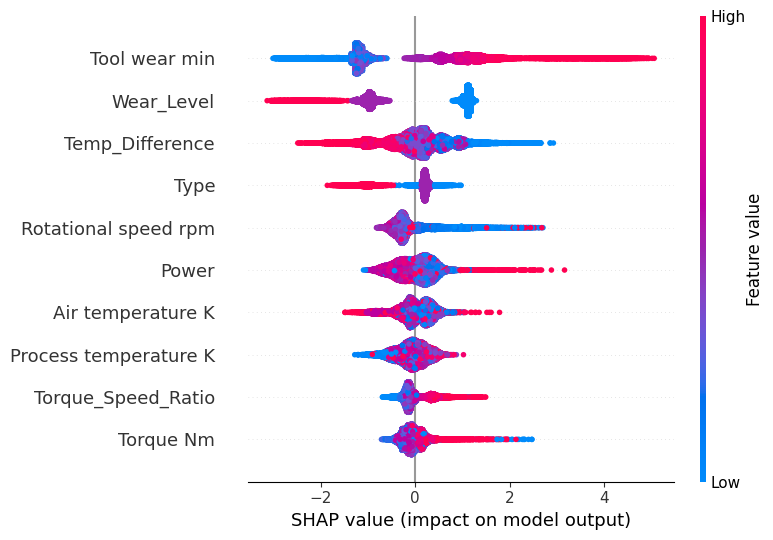

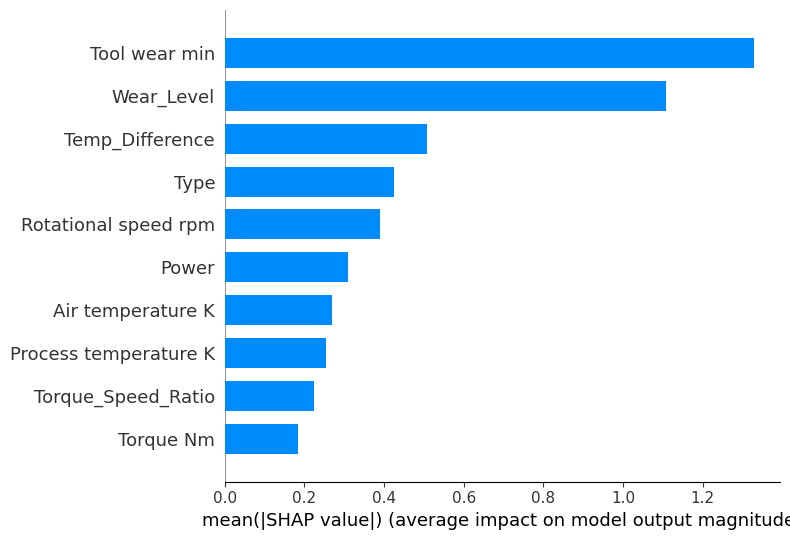

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.Explainer(best_xgb, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

# Global summary plot
shap.summary_plot(shap_values, X_test)

# Bar plot of feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

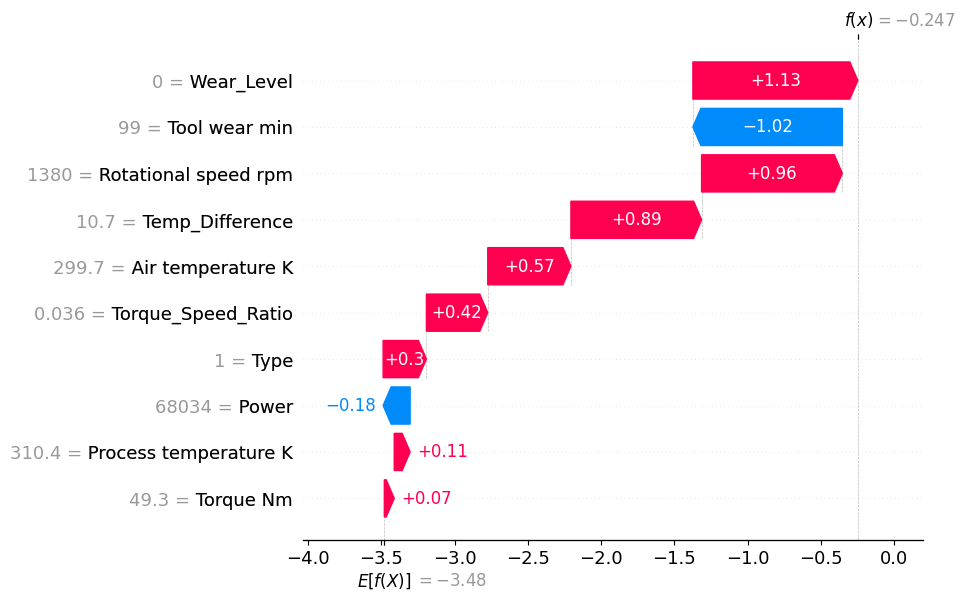

In [ ]:
# Get an actual failure sample
failure_indices = X_test[y_test == 1].index
failure_idx = failure_indices[0]

# Convert index label to positional index
sample_position = X_test.index.get_loc(failure_idx)

# Waterfall plot for one failure case
shap.plots.waterfall(shap_values[sample_position])

In [ ]:
df_model[["Tool wear [min]", "Wear_Level"]].corr()

,Tool wear [min],Wear_Level
Tool wear [min],1.000000,0.879196
Wear_Level,0.879196,1.000000


In [ ]:
df_model[[
    "Process temperature [K]",
    "Air temperature [K]",
    "Temp_Difference"
]].corr()

,Process temperature [K],Air temperature [K],Temp_Difference
Process temperature [K],1.000000,0.856080,-0.212257
Air temperature [K],0.856080,1.000000,-0.686776
Temp_Difference,-0.212257,-0.686776,1.000000


In [ ]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_Difference', 'Power', 'Failure Type', 'Torque_Speed_Ratio',
       'Wear_Level'],
      dtype='object')

In [ ]:
import pickle

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

In [ ]:
X_train_resm.columns

Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temp_Difference',
       'Power', 'Torque_Speed_Ratio', 'Wear_Level'],
      dtype='object')

In [ ]:
X_train_resm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214850 entries, 0 to 214849
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Type                   214850 non-null  int64  
 1   Air temperature K      214850 non-null  float64
 2   Process temperature K  214850 non-null  float64
 3   Rotational speed rpm   214850 non-null  int64  
 4   Torque Nm              214850 non-null  float64
 5   Tool wear min          214850 non-null  int64  
 6   Temp_Difference        214850 non-null  float64
 7   Power                  214850 non-null  float64
 8   Torque_Speed_Ratio     214850 non-null  float64
 9   Wear_Level             214850 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 16.4 MB


In [ ]:
X_train.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Temp_Difference', 'Power', 'Torque_Speed_Ratio', 'Wear_Level'],
      dtype='object')

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109143 entries, 72862 to 83333
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Type                     109143 non-null  int64  
 1   Air temperature [K]      109143 non-null  float64
 2   Process temperature [K]  109143 non-null  float64
 3   Rotational speed [rpm]   109143 non-null  int64  
 4   Torque [Nm]              109143 non-null  float64
 5   Tool wear [min]          109143 non-null  int64  
 6   Temp_Difference          109143 non-null  float64
 7   Power                    109143 non-null  float64
 8   Torque_Speed_Ratio       109143 non-null  float64
 9   Wear_Level               109143 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 9.2 MB


In [ ]:
X_test.columns

Index(['Type', 'Air temperature K', 'Process temperature K',
       'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temp_Difference',
       'Power', 'Torque_Speed_Ratio', 'Wear_Level'],
      dtype='object')

In [ ]:
X_test.to_csv('test_data_csv.csv', index=False)

In [ ]:
X_train.to_csv("train_data.csv", index=False)